In [3]:
import os
os.environ["HF_HOME"] = "/raid/s3/opengptx/behzad_shomali/custom_hf_cache/"

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


ModuleNotFoundError: No module named 'trl'

In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 155.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 105.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 126.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [18]:
from pathlib import Path
import os

In [21]:
# get home directory
home = str(Path.home())
path = Path(os.path.join(home, "results/results/swiss-ai/Apertus-8B-2509"))

In [22]:
list(path.glob("results_*.json"))

[PosixPath('/home/behzad_shomali/results/results/swiss-ai/Apertus-8B-2509/results_2025-09-18T17-18-54.123879.json'),
 PosixPath('/home/behzad_shomali/results/results/swiss-ai/Apertus-8B-2509/results_2025-09-18T17-34-16.231805.json'),
 PosixPath('/home/behzad_shomali/results/results/swiss-ai/Apertus-8B-2509/results_2025-09-18T17-28-41.166787.json'),
 PosixPath('/home/behzad_shomali/results/results/swiss-ai/Apertus-8B-2509/results_2025-09-18T16-49-06.821131.json')]

In [4]:
import torch, torchvision, torchaudio
print(torch.__version__)        # 2.7.1+cu126
print(torch.version.cuda)       # 12.6
print(torch.backends.cudnn.version())
print(torchvision.__version__)  # 0.15.2+cu126
print(torchaudio.__version__)

2.7.1+cu126
12.6
90501
0.22.1+cu126
2.7.1+cu126


In [1]:
import torch, torchvision, torchaudio
print(torch.__version__)        # 2.7.1+cu126
print(torch.version.cuda)       # 12.6
print(torch.backends.cudnn.version())
print(torchvision.__version__)  # 0.15.2+cu126
print(torchaudio.__version__)

2.7.1+cu126
12.6
90501
0.22.1+cu126
2.7.1+cu126


In [1]:
import torch
print(torch.version.cuda)
print(torch.backends.cudnn.version())
print(torch.__version__)

12.6
91002
2.8.0+cu126


In [1]:
import torch
print(torch.version.cuda)
print(torch.backends.cudnn.version())
print(torch.__version__)

12.6
90501
2.7.1+cu126


In [1]:
import numpy as np
print(np.version)

<module 'numpy.version' from '/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/numpy/version.py'>


In [5]:
print(torch.backends.cuda.is_bf16_supported())

AttributeError: module 'torch.backends.cuda' has no attribute 'is_bf16_supported'

In [8]:
# ---- Settings ----
# base_model_name = "meta-llama/Llama-3.2-3B"
# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-18_41_56/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-20_53_57/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_02-11_13_11/checkpoint-2000/lora_merged/"

base_model_name = "Behzadshomali/Teuken3.7B"
finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.7B_IT_OpenMathInstruct-2/2025_09_05-17_03_49_Teuken3.7B_IT_OpenMathInstruct-2/2025_09_06-12_39_29_lora+_rank16_alpha32_1M(Markus)/2025_09_06-12_43_26/checkpoint-30000/lora_merged/"

sample_text = "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?"

# ---- Load models ----
base_model = AutoModel.from_pretrained(base_model_name, output_hidden_states=True, trust_remote_code=True)
ft_model = AutoModel.from_pretrained(finetuned_model_name, output_hidden_states=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

if tokenizer.chat_template is None:
    base_model, tokenizer = setup_chat_format(base_model, tokenizer)

# Put models in eval mode
base_model.eval()
ft_model.eval()


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 317.68it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


GPT2Model(
  (embed_tokens): Embedding(250887, 4096, padding_idx=250886)
  (layers): ModuleList(
    (0-31): 32 x GPT2DecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
        (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
        (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
        (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
        (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    )
  )
  (norm): LayerNorm((4096,), eps=1e-05, elementwise_affine=Tru

In [9]:
# ---- Weight Differences ----
weight_diffs = []
layer_names = []

with torch.no_grad():
    for (n1, p1), (n2, p2) in zip(base_model.named_parameters(), ft_model.named_parameters()):
        if p1.shape == p2.shape:
            diff = (p1 - p2).abs().mean().item()
            weight_diffs.append(diff)
            layer_names.append(n1)
        else:
            print(f"Skipping {n1} due to shape mismatch: {p1.shape} vs {p2.shape}")

# ---- Activation Differences ----
inputs = tokenizer(sample_text, return_tensors="pt")

with torch.no_grad():
    base_out = base_model(**inputs)
    ft_out = ft_model(**inputs)

# Extract hidden states (list of [batch, seq_len, hidden_size])
base_hs = base_out.hidden_states
ft_hs = ft_out.hidden_states

act_diffs = []
layer_ids = list(range(len(base_hs)))

for h1, h2 in zip(base_hs, ft_hs):
    diff = (h1.mean(dim=(0,1)) - h2.mean(dim=(0,1))).abs().mean().item()
    act_diffs.append(diff)



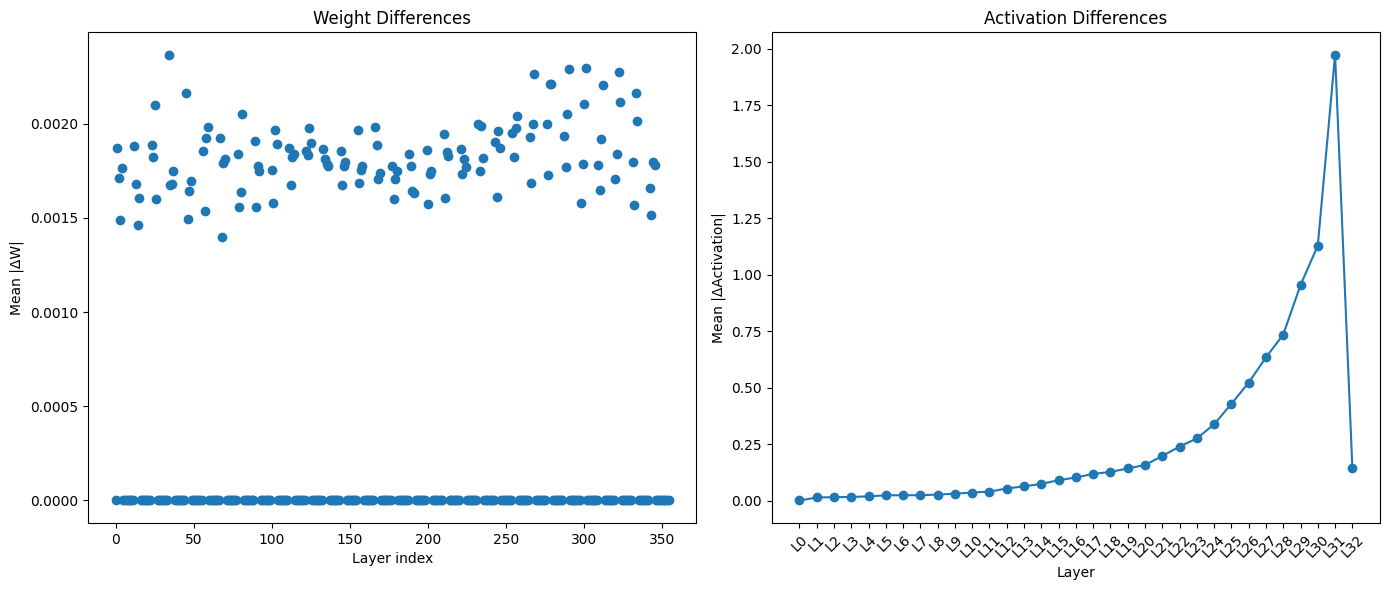

In [10]:
# ---- Plot ----
plt.figure(figsize=(14,6))

# Plot weight differences
plt.subplot(1,2,1)
plt.scatter(range(len(weight_diffs)), weight_diffs, marker='o')
plt.title("Weight Differences")
plt.xlabel("Layer index")
plt.ylabel("Mean |ΔW|")
plt.tight_layout()

# Plot activation differences
plt.subplot(1,2,2)
plt.plot(layer_ids, act_diffs, marker='o')
plt.xticks(range(len(layer_ids)), [f"L{i}" for i in layer_ids], rotation=45)
plt.title("Activation Differences")
plt.xlabel("Layer")
plt.ylabel("Mean |ΔActivation|")

plt.tight_layout()
plt.show()

In [11]:
for i in range(len(weight_diffs)):
    print(f"Layer {layer_names[i]} --> Weight Diff = {weight_diffs[i]:.6f}")

Layer embed_tokens.weight --> Weight Diff = 0.000004
Layer layers.0.self_attn.q_proj.weight --> Weight Diff = 0.001869
Layer layers.0.self_attn.k_proj.weight --> Weight Diff = 0.001713
Layer layers.0.self_attn.v_proj.weight --> Weight Diff = 0.001491
Layer layers.0.self_attn.o_proj.weight --> Weight Diff = 0.001768
Layer layers.0.mlp.gate_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.up_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.down_proj.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.bias --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.bias --> Weight Diff = 0.000000
Layer layers.1.self_attn.q_proj.weight --> Weight Diff = 0.001880
Layer layers.1.self_attn.k_proj.weight --> Weight Diff = 0.001682
Layer layers.1.self_attn.v_proj.weight --> Weight Diff = 0.001460
Layer layers.1.self_attn

In [1]:
from pathlib import Path

In [8]:
file_dir = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/"
file_dir = Path(file_dir)
json_files = [f for f in file_dir.glob("*.json") if f.is_file() and "results" in f.name]
json_files

[PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T16-24-08.464414.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-06-05.599449.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-23-45.980589.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T15-53-26.500130.json')]

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from transformers import AutoConfig, AutoModelForCausalLM


model_names = [
    "Behzadshomali/Teuken3.7B",
    "meta-llama/Llama-3.1-8B",
    "meta-llama/Llama-3.2-3B"
]

for model_name in model_names:
    print("=="*10, f"Model: {model_name}", "=="*10)
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

    print("Number of hidden layers:", config.num_hidden_layers)

    # If you load the model, you can also count directly:
    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
    print("Layers in transformer:", len(model.model.layers))
    print()

    del model

The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


==================== Model: Behzadshomali/Teuken3.7B ====================


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


Number of hidden layers: 32


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.1-8B ====================
Number of hidden layers: 32


Loading checkpoint shards: 100%|██████████| 4/4 [00:15<00:00,  3.81s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.2-3B ====================
Number of hidden layers: 28


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.24s/it]


Layers in transformer: 28



In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
model = AutoModelForCausalLM.from_pretrained("Behzadshomali/Teuken3.7B", torch_dtype=torch.bfloat16, trust_remote_code=True)
# tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4

In [11]:
model

GPT2ForCausalLM(
  (model): GPT2Model(
    (embed_tokens): Embedding(250880, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x GPT2DecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
      )
    )
 

In [ ]:
dummy_input = torch.tensor([[12, 34, 56, 78, 90]])
input_embeddings = model.get_input_embeddings()(dummy_input)


In [9]:
logits = model(input_ids=dummy_input).logits
logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [14]:
model(inputs_embeds=input_embeddings).logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [ ]:
model.get_input_embeddings().weight

torch.Size([250880, 4096])

In [10]:
torch.matmul(logits, model.get_input_embeddings().weight).shape

torch.Size([1, 5, 4096])

In [4]:
input_embeddings.shape

torch.Size([1, 5, 4096])

In [5]:
logits.shape

torch.Size([1, 5, 250880])

In [2]:
model = AutoModelForCausalLM.from_pretrained("tomg-group-umd/huginn-0125", torch_dtype=torch.bfloat16, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_config_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_modeling_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin 

In [3]:
model

RavenForCausalLM(
  (transformer): ModuleDict(
    (wte): Embedding(65536, 5280)
    (prelude): ModuleList(
      (0-1): 2 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_features=5280, bias=False)
        )
        (norm_2): RMSNorm()
        (mlp): GatedMLP(
          (fc): Linear(in_features=5280, out_features=35840, bias=False)
          (proj): Linear(in_features=17920, out_features=5280, bias=False)
          (nonlin): SiLU()
        )
        (norm_3): RMSNorm()
        (norm_4): RMSNorm()
      )
    )
    (adapter): Linear(in_features=10560, out_features=5280, bias=False)
    (core_block): ModuleList(
      (0-3): 4 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_feature

In [15]:
import torch
import torch.nn as nn
from pydantic import BaseModel
from typing import Any, Dict, Optional, Tuple
from torch import Tensor
from dataclasses import dataclass


@dataclass
class PonderingModelConfig(BaseModel):
    """Configuration for registering with Modalities."""
    base_model_config: Dict[str, Any]
    pondering_steps: int = 3
    pondering_position: str = "after_embed"
    hidden_size: int = 768
    num_attention_heads: int = 12
    intermediate_size: int = 3072
    dropout: float = 0.1

In [16]:
PonderingModelConfig.model_fields

{'base_model_config': FieldInfo(annotation=Dict[str, Any], required=True),
 'pondering_steps': FieldInfo(annotation=int, required=False, default=3),
 'pondering_position': FieldInfo(annotation=str, required=False, default='after_embed'),
 'hidden_size': FieldInfo(annotation=int, required=False, default=768),
 'num_attention_heads': FieldInfo(annotation=int, required=False, default=12),
 'intermediate_size': FieldInfo(annotation=int, required=False, default=3072),
 'dropout': FieldInfo(annotation=float, required=False, default=0.1)}

In [1]:
# !pip install pydantic==1.10

In [11]:
from pydantic import BaseModel, Field
from typing import Annotated

class ModelExample(BaseModel):
    x: int = Field(...)

# Try instantiating
try:
    # This will fail in Pydantic v1 if type is wrong
    m = ModelExample(x='123', strict=True)  # string instead of int
    print("Instantiated:", m, type(m.x))
except Exception as e:
    print("Error:", e)

# Try passing strict=True in constructor
# try:
#     m2 = ModelExample(x="12ds3", strict=False)
#     print("Instantiated with strict=True:", m2, type(m2.x))
# except TypeError as e:
#     print("TypeError:", e)

Instantiated: x=123 <class 'int'>
